# Batch Normalization

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
dataset = pd.read_csv(r"C:\Users\imrat\OneDrive\Desktop\data_science_all_uses_items\Data_set\Churn_Modelling.csv")
dataset.head(3)
dataset.drop(columns=["RowNumber","CustomerId","Surname","Geography","Gender"],inplace=True)


In [4]:
input_data = dataset.iloc[:,:-1]
output_data = dataset.iloc[:,-1]

In [5]:
sc = StandardScaler()
input_data = pd.DataFrame(sc.fit_transform(input_data),columns=input_data.columns)

In [6]:
from sklearn.model_selection import train_test_split

In [16]:
x_train,x_test,y_train,y_test = train_test_split(input_data,output_data,random_state=42,test_size=0.2)

In [17]:
import tensorflow

In [50]:
from keras.layers import Dense
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.regularizers import L2

In [25]:
ann = Sequential()

In [77]:
# kernel_regulaization l1,l2 and l1,l2
ann.add(Dense(6,input_dim=8,activation="relu",kernel_regularizer=L2(l2=0.01)))
ann.add(Dense(4,activation="relu",kernel_regularizer=L2(l2=0.01)))
ann.add(Dense(2,activation="relu",kernel_regularizer=L2(l2=0.01)))
ann.add(Dense(1,activation="sigmoid",kernel_regularizer=L2(l2=0.01)))

C:\Users\imrat\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [78]:
ann.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [79]:
ann.fit(x_train,y_train,batch_size=100,epochs=50,validation_data=(x_test,y_test),callbacks=EarlyStopping())

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7945 - loss: 0.7536 - val_accuracy: 0.8035 - val_loss: 0.7311
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7945 - loss: 0.7132 - val_accuracy: 0.8035 - val_loss: 0.6941
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7945 - loss: 0.6801 - val_accuracy: 0.8035 - val_loss: 0.6633
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7945 - loss: 0.6526 - val_accuracy: 0.8035 - val_loss: 0.6377
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7945 - loss: 0.6298 - val_accuracy: 0.8035 - val_loss: 0.6163
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7945 - loss: 0.6107 - val_accuracy: 0.8035 - val_loss: 0.5982
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7945 - loss: 0.5946 - val_accuracy: 0.8035 - val_loss: 0.5830
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7945 - loss: 0.5810 - val_accuracy: 0.8035 - val_loss

In [65]:
train_accuracy = ann.history.history["accuracy"]
test_accuracy = ann.history.history["val_accuracy"]

In [66]:
import matplotlib.pyplot as plt

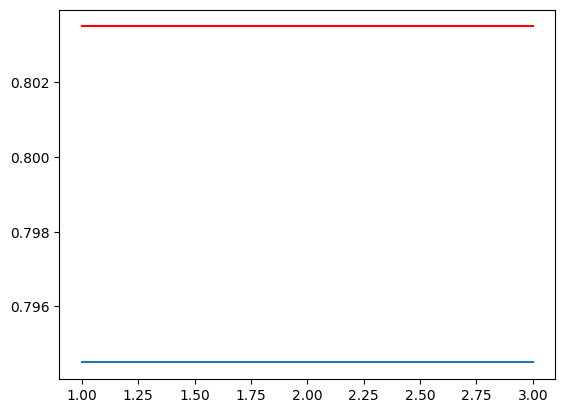

In [67]:
plt.plot([i for i in range(1,4)],train_accuracy)
plt.plot([i for i in range(1,4)],test_accuracy,c="red")
plt.show()

In [68]:
from sklearn.metrics import accuracy_score

In [69]:
prd = ann.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [70]:
prd_data = []
for i in prd:
    if i[0]>0.5:
        prd_data.append(1)
    else:
        prd_data.append(0)

In [71]:
accuracy_score(y_test,prd_data)*100

80.35

In [72]:
prd1 = ann.predict(x_train)

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [73]:
prd1_data = []
for i in prd1:
    if i[0]>0.5:
        prd1_data.append(1)
    else:
        prd1_data.append(0)

In [74]:
accuracy_score(y_train,prd1_data)*100

79.45

In [75]:
new_data = np.array([[-0.564197, -0.660018, -0.695982, 0.324119, 0.807737, -1.547768, -1.030670, -1.013811]])
prd = ann.predict(new_data)
prd_data = []
for i in prd:
    if i[0]>0.5:
        prd_data.append(1)
    else:
        prd_data.append(0)
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


In [76]:
prd_data

[0]

In [1]:
import pandas as pd
import numpy as np


In [2]:
dataset = pd.read_csv(r"C:\Users\imrat\OneDrive\Desktop\data_science_all_uses_items\Data_set\Churn_Modelling.csv")
dataset.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [3]:
dataset.drop(columns=["RowNumber","CustomerId","Surname","Geography","Gender"],inplace=True)

In [4]:
input_data = dataset.iloc[:,:-1]
output_data = dataset.iloc[:,-1]

In [5]:
from sklearn.preprocessing import StandardScaler

In [8]:
ss = StandardScaler()
input_data = pd.DataFrame(ss.fit_transform(input_data),columns=input_data.columns)

In [9]:
input_data.head(3)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534
2,-1.536794,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x_train,x_test,y_train,y_test = train_test_split(input_data,output_data,test_size=0.2,random_state=42)

In [12]:
import tensorflow

In [33]:
from keras.layers import BatchNormalization
from keras.layers import Dense
from keras.regularizers import L2
from keras.callbacks import EarlyStopping
from keras.models import Sequential

In [15]:
ann = Sequential()

In [34]:
ann.add(Dense(6,input_dim=8,activation="relu",kernel_regularizer=L2(l2=0.01)))
ann.add(BatchNormalization())
ann.add(Dense(5,activation="relu",kernel_regularizer=L2(l2=0.01)))
ann.add(BatchNormalization())
ann.add(Dense(3,activation="relu",kernel_regularizer=L2(l2=0.01)))
ann.add(BatchNormalization())
ann.add(Dense(1,activation="sigmoid"))

C:\Users\imrat\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
ann.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [44]:
ann.fit(x_train,y_train,batch_size=200,epochs=10,validation_data = (x_test,y_test),callbacks=EarlyStopping())

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7136 - loss: 0.8431 - val_accuracy: 0.8035 - val_loss: 0.8290
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7595 - loss: 0.7924 - val_accuracy: 0.8035 - val_loss: 0.7812
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7818 - loss: 0.7473 - val_accuracy: 0.8035 - val_loss: 0.7281
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7871 - loss: 0.7069 - val_accuracy: 0.8035 - val_loss: 0.6923
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7915 - loss: 0.6697 - val_accuracy: 0.8035 - val_loss: 0.6665
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7940 - loss: 0.6369 - val_accuracy: 0.8035 - val_loss: 0.6415
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7940 - loss: 0.6081 - val_accuracy: 0.8035 - val_loss: 0.6362
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7949 - loss: 0.5819 - val_accuracy: 0.8035 - val_loss:

In [45]:
prd = ann.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [46]:
prd_data = []
for i in prd:
    if i[0]>0.5:
        prd_data.append(1)
    else:
        prd_data.append(0)

In [47]:
from sklearn.metrics import accuracy_score

In [48]:
accuracy_score(y_test,prd_data)*100

80.35

In [49]:
prd1 = ann.predict(x_train)

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [50]:
prd_data1 = []
for i in prd1:
    if i[0] >0.5:
        prd_data1.append(1)
    else:
        prd_data1.append(0)

In [51]:
accuracy_score(y_train,prd_data1)*100

79.45

# Dropout Layer

In [52]:
import pandas as pd
import numpy as np

In [53]:
dataset = pd.read_csv(r"C:\Users\imrat\OneDrive\Desktop\data_science_all_uses_items\Data_set\Churn_Modelling.csv")
dataset.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [54]:
dataset.drop(columns=["RowNumber","CustomerId","Surname","Geography","Gender"],inplace=True)

In [55]:
dataset.head(3)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,42,2,0.00,1,1,1,101348.88,1
1,608,41,1,83807.86,1,0,1,112542.58,0
2,502,42,8,159660.80,3,1,0,113931.57,1


In [56]:
input_data = dataset.iloc[:,:-1]
output_data = dataset.iloc[:,-1]


In [57]:
from sklearn.preprocessing import StandardScaler

In [58]:
ss = StandardScaler()

In [60]:
input_data = pd.DataFrame(ss.fit_transform(input_data),columns=input_data.columns)

In [61]:
from sklearn.model_selection import train_test_split

In [62]:
x_train,x_test,y_train,y_test = train_test_split(input_data,output_data,random_state=42,test_size=0.2)

In [63]:
import tensorflow

In [88]:
from keras.layers import BatchNormalization
from keras.layers import Dropout
from keras.layers import Dense
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.regularizers import L2

In [66]:
ann = Sequential()
kernel_regularizer=L2(l2=0.01)

In [100]:
ann.add(Dense(6,input_dim=8,activation="relu",kernel_regularizer=L2(l2=0.01)))
ann.add(BatchNormalization())
ann.add(Dense(5,activation="relu",kernel_regularizer=L2(l2=0.01)))
ann.add(BatchNormalization())
ann.add(Dense(3,activation="relu",kernel_regularizer=L2(l2=0.01)))
ann.add(BatchNormalization())
ann.add(Dropout(0.3))
ann.add(Dense(1,activation="sigmoid",kernel_regularizer=L2(l2=0.01)))

C:\Users\imrat\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [101]:
ann.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [102]:
ann.fit(x_train,y_train,batch_size=200,epochs=10,validation_data = (x_test,y_test),callbacks=EarlyStopping())

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.5444 - loss: 0.8558 - val_accuracy: 0.8035 - val_loss: 0.8238
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6747 - loss: 0.8123 - val_accuracy: 0.8035 - val_loss: 0.7840
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7234 - loss: 0.7733 - val_accuracy: 0.8035 - val_loss: 0.7474
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7570 - loss: 0.7426 - val_accuracy: 0.8035 - val_loss: 0.7131
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7797 - loss: 0.7079 - val_accuracy: 0.8035 - val_loss: 0.6787
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7880 - loss: 0.6809 - val_accuracy: 0.8035 - val_loss: 0.6491
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7930 - loss: 0.6539 - val_accuracy: 0.8035 - val_loss: 0.6236
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7993 - loss: 0.6248 - val_accuracy: 0.8035 - val_loss

In [103]:
prd = ann.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [109]:
prd_data = []
for i in prd:
    if i[0]>0.5:
        prd_data.append(1)
    else:
        prd_data.append(0)

In [110]:
from sklearn.metrics import accuracy_score

In [111]:
accuracy_score(y_test,prd_data)*100

80.35

In [112]:
prd1 = ann.predict(x_train)

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [113]:
prd_data1 = []
for i in prd1:
    if i[0]>0.5:
        prd_data1.append(1)
    else:
        prd_data1.append(0)

In [114]:
accuracy_score(y_train,prd_data1)*100

79.45